In [131]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.patches as mpatches
from psynlig import pca_2d_scores
import matplotlib.patches as mpatches
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from scipy import stats
from matplotlib.patches import FancyArrowPatch

In [132]:
emma_data = pd.read_csv('../data/FullData.txt', sep='\t')

In [133]:
viruses_eq = pd.read_csv('../data/aminoacid_eq_freq_all_virus.csv')
viruses_aa_freq = pd.read_csv('../data/aminoacid_freq_all_virus.csv')
viruses_type = pd.read_csv('../data/taxid_virus_type.csv', index_col=0)

d = {'C': 'Cys', 'D': 'Asp', 'S': 'Ser', 'Q': 'Gln', 'K': 'Lys',
     'I': 'Ile', 'P': 'Pro', 'T': 'Thr', 'F': 'Phe', 'N': 'Asn', 
     'G': 'Gly', 'H': 'His', 'L': 'Leu', 'R': 'Arg', 'W': 'Trp', 
     'A': 'Ala', 'V':'Val', 'E': 'Glu', 'Y': 'Tyr', 'M': 'Met'}

viruses_aa_freq.columns = [d[col] if col in d else col for col in viruses_aa_freq.columns]
viruses_eq.columns = [d[col] if col in d else col for col in viruses_eq.columns]
emma_data.columns = [d[col] if col in d else col for col in emma_data.columns]
viruses_type['taxid'] = viruses_type['taxid'].apply(str)
viruses_eq['taxid'] = viruses_eq['taxid'].apply(str)
viruses_aa_freq['taxid'] = viruses_aa_freq['taxid'].apply(str)

viruses_type = viruses_type[['taxid', 'Type']]

In [134]:
viruses_aa_freq = viruses_aa_freq[viruses_aa_freq['taxid'].isin(list(viruses_eq['taxid'].unique()))]
viruses_eq = viruses_eq.merge(viruses_type, how='left', on='taxid')
viruses_aa_freq = viruses_aa_freq.merge(viruses_type, how='left', on='taxid')

viruses_eq.loc[viruses_eq['Type'] == '+','Strand'] = 'positive '
viruses_eq.loc[viruses_eq['Type'] == '+','Species'] = 'Ideal positive'
viruses_eq.loc[viruses_eq['Type'] == '-','Strand'] = 'negative'
viruses_eq.loc[viruses_eq['Type'] == '-','Species'] = 'Ideal negative'
viruses_eq.loc[viruses_eq['Type'] == 'ds','Strand'] = 'double'
viruses_eq.loc[viruses_eq['Type'] == 'ds','Species'] = 'Ideal double'

viruses_eq = viruses_eq.drop(['Type'], axis=1)

viruses_aa_freq.loc[viruses_aa_freq['Type'] == '+','Strand'] = 'positive '
viruses_aa_freq.loc[viruses_aa_freq['Type'] == '+','Species'] = 'Ref positive'
viruses_aa_freq.loc[viruses_aa_freq['Type'] == '-','Strand'] = 'negative'
viruses_aa_freq.loc[viruses_aa_freq['Type'] == '-','Species'] = 'Ref negative'
viruses_aa_freq.loc[viruses_aa_freq['Type'] == 'ds','Strand'] = 'double'
viruses_aa_freq.loc[viruses_aa_freq['Type'] == 'ds','Species'] = 'Ref double'

viruses_aa_freq = viruses_aa_freq.drop(['Type'], axis=1)

In [135]:
emma_data = emma_data.append(viruses_eq)
emma_data = emma_data.append(viruses_aa_freq)

C:\Users\voron\AppData\Local\Temp\ipykernel_68492\3709174602.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  emma_data = emma_data.append(viruses_eq)
C:\Users\voron\AppData\Local\Temp\ipykernel_68492\3709174602.py:2: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  emma_data = emma_data.append(viruses_aa_freq)


In [136]:
emma_data_train = emma_data[emma_data['Family'] != 'Coronaviridae']

In [137]:
emma_data_train = emma_data[emma_data['taxid'].isna()]
emma_data_transform = emma_data
for_pca_train = emma_data_train[emma_data_train.columns[5:-3]].reset_index(drop=True)

for_pca_train['total'] = for_pca_train.sum(axis=1)
for col in emma_data[emma_data_train.columns[5:-3]].columns:
    for_pca_train[col] = for_pca_train[col]/for_pca_train['total']
for_pca_train = for_pca_train.drop('total',axis=1)
for_pca_train = for_pca_train.fillna(0)

for_pca_transform = emma_data_transform[emma_data_transform.columns[5:-3]].reset_index(drop=True)
for_pca_transform['total'] = for_pca_transform.sum(axis=1)
for col in emma_data[emma_data_transform.columns[5:-3]].columns:
    for_pca_transform[col] = for_pca_transform[col]/for_pca_transform['total']
for_pca_transform = for_pca_transform.drop('total',axis=1)
for_pca_transform = for_pca_transform.fillna(0)

model = PCA(n_components=2)
pca_fit = model.fit(for_pca_train)
pca_model = pca_fit.transform(for_pca_transform)
#pca_data = pd.DataFrame(pca_model, columns=["pc"+str(i+1) for i in range(len(for_pca.columns))])
pca_data = pd.DataFrame(pca_model, columns=["pc1", 'pc2'])
pca_data1 = pca_data[["pc1","pc2"]].copy()

pca_data1['Family'] = emma_data['Family'].reset_index(drop=True)

In [138]:
pca_data1['strand'] = emma_data['Strand'].to_list()
pca_data1['Species'] = emma_data['Species'].to_list()
pca_data1['taxid'] = emma_data['taxid'].to_list()

In [139]:
ref_data = pca_data1[pca_data1['Species'].isin(['Ref negative', 'Ref positive', 'Ref double'])]
ideal_data = pca_data1[pca_data1['Species'].isin(['Ideal negative', 'Ideal positive', 'Ideal double'])]

In [140]:
viruses_short_names = pd.read_csv('../data/viral_spectra_dataset.csv')
viruses_short_names['taxid'] = viruses_short_names['taxid'].apply(str)
viruses_short_names = viruses_short_names[['taxid', 'virusname']]
ideal_data = ideal_data.merge(viruses_short_names, how='left', on='taxid')

In [141]:
sum_vectors = ideal_data[['pc1', 'pc2', 'strand', 'taxid']].rename(columns={'pc1': 'pc1_fin', 'pc2': 'pc2_fin'})
sum_vectors = sum_vectors.merge(ref_data[['pc1', 'pc2', 'taxid']], how='left', on='taxid')
sum_vectors['x'] = sum_vectors['pc1_fin'] - sum_vectors['pc1']
sum_vectors['y'] = sum_vectors['pc2_fin'] - sum_vectors['pc2']

In [142]:
sum_vectors = sum_vectors[['x', 'y', 'strand']].groupby('strand').mean().reset_index()

C:\Users\voron\AppData\Local\Temp\ipykernel_68492\205280919.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ideal_genomes.loc[ideal_genomes['strand']=='positive ', 'color'] = 'green'


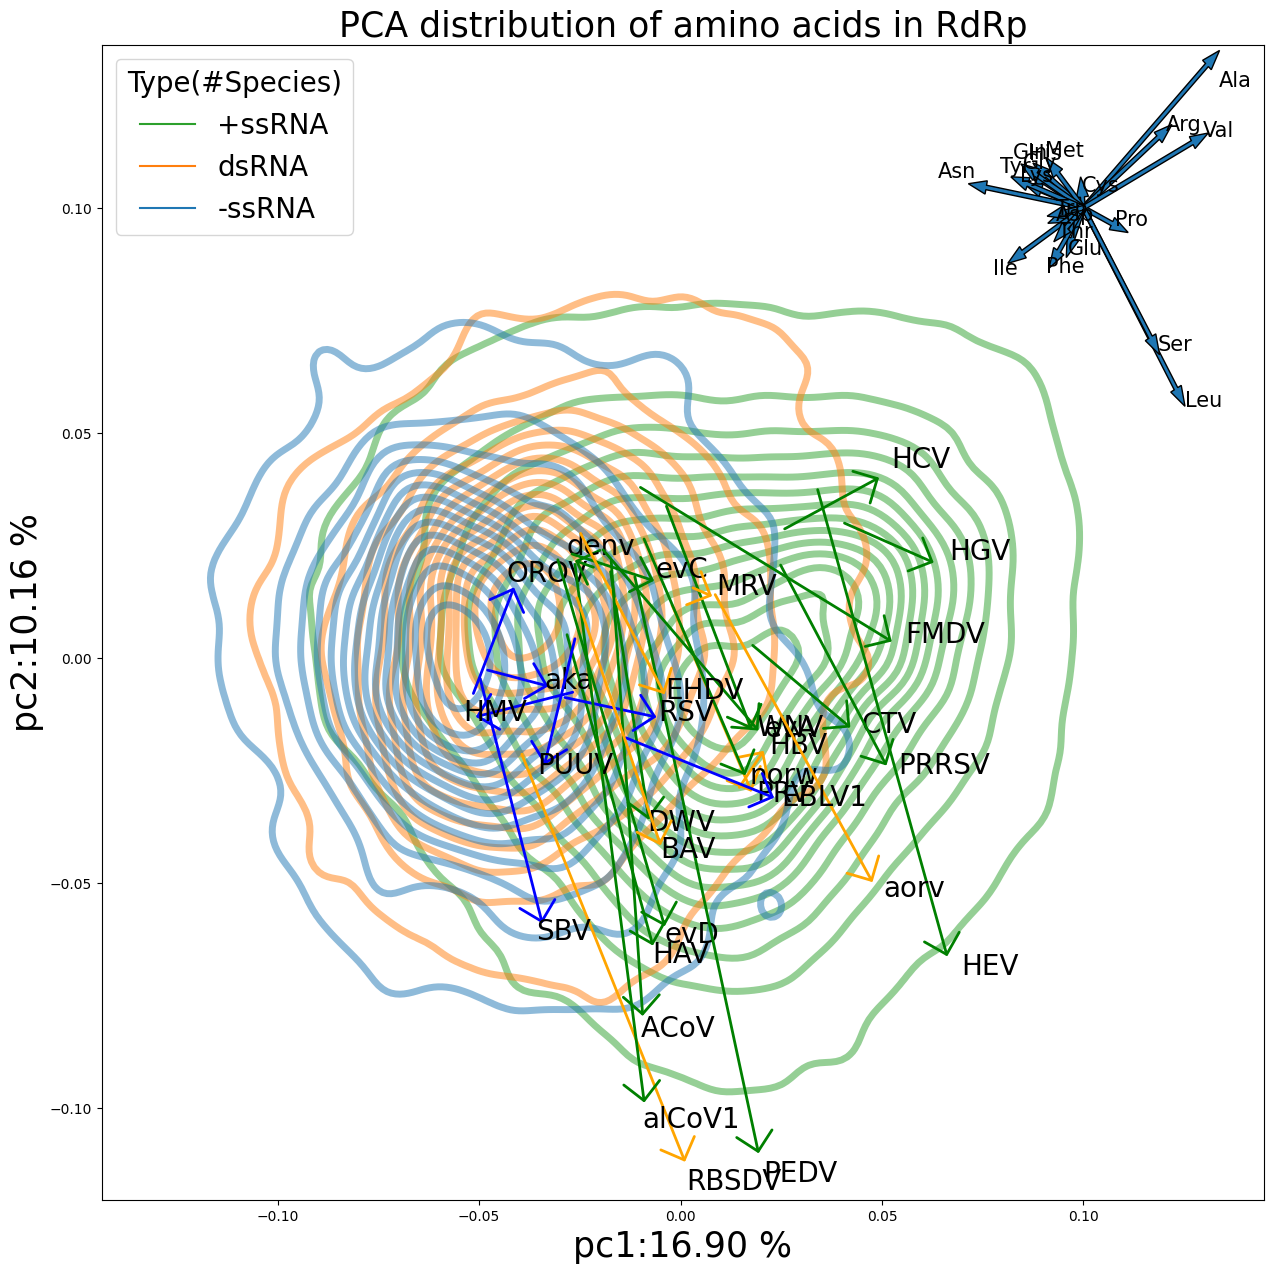

In [30]:
features = for_pca_train.columns
ldngs = pca_fit.components_
pca_data1['for_legend'] = ''
pca_data1.loc[pca_data1['strand'] == 'positive ','Type(#Species)'] = '+ssRNA'
pca_data1.loc[pca_data1['strand'] == 'negative' ,'Type(#Species)'] = '-ssRNA'
pca_data1.loc[pca_data1['strand'] == 'double' ,'Type(#Species)'] = 'dsRNA'

palette = {
    'dsRNA': 'tab:orange',
    '+ssRNA': 'tab:green',
    '-ssRNA': 'tab:blue'
}
plt.rcParams["figure.figsize"] = (15,15)
plt.rcParams['legend.fontsize'] = 20
plt.rcParams["legend.title_fontsize"] = 20
#plt.xlim([-0.23positive Coronaviridae,0.23]) 
#plt.ylim([-0.23,;.0.23])
g=sns.kdeplot(data=pca_data1[pca_data1['taxid'].isna()], x="pc1", y="pc2", hue="Type(#Species)", 
              alpha=0.5, palette=palette, legend=True, thresh=0.01, levels=15, common_norm=False, linewidths=5)
#, xlim = (-10,12), ylim = (-10,10))

ideal_genomes = pca_data1[pca_data1['Species'].isin(['Ideal positive','Ideal negative','Ideal double'])]
ideal_genomes.loc[ideal_genomes['taxid'].isin(['694014', '693997']),'strand'] = 'positive Coronaviridae'
ideal_genomes.loc[ideal_genomes['strand']=='positive ', 'color'] = 'green'
#ideal_genomes.loc[ideal_genomes['strand']=='positive Coronaviridae ', 'color'] = 'red'
ideal_genomes.loc[ideal_genomes['strand']=='double', 'color'] = 'orange'
ideal_genomes.loc[ideal_genomes['strand']=='negative', 'color'] = 'blue'
xs = ideal_genomes['pc1']
ys = ideal_genomes['pc2']
colors = ideal_genomes['color']

#plt.legend(fontsize='x-large', title_fontsize='40') 
# plot the points
#plt.scatter(xs,ys, c=colors)
#plt.legend(["positive" , "negative", 'double'])
#plt.legend()
#ref_data.loc[ref_data['taxid'].isin(['694014', '693997']),'strand'] = 'positive Coronaviridae'

for index, row in ref_data.iterrows():
    ref_index = ref_data['taxid'][index]
    x_start = ref_data['pc1'][index]
    y_start = ref_data['pc2'][index]
    x_finish = ideal_data.loc[ideal_data['taxid'] == ref_index, 'pc1'].values[0]
    y_finish = ideal_data.loc[ideal_data['taxid'] == ref_index, 'pc2'].values[0]
    virus_short_name = ideal_data.loc[ideal_data['taxid'] == ref_index, 'virusname'].values[0]
    if ref_data['strand'][index]=='positive ':
        color='green'
    elif ref_data['strand'][index]=='double':
        color='orange'
    elif ref_data['strand'][index]=='negative':
        color='blue'
    #elif ref_data['strand'][index]=='positive Coronaviridae':
    #    color='red'
    plt.annotate("",
            xy=(x_finish, y_finish), xycoords='data',
            xytext=(x_start, y_start), textcoords='data',
            arrowprops=dict(arrowstyle="->, head_width=1.3, head_length=1.3", connectionstyle="arc3", linewidth=2, 
                            color=color))
    plt.text(x_finish * 1.05, 
                    y_finish * 1.05, 
                    virus_short_name, fontsize=20)
    
for i, feature in enumerate(features):
    plt.arrow(0.1, 0.1, ldngs[0, i]/15, 
             ldngs[1, i]/15)
    if ldngs[0, i]/5 > (ldngs[0]/5).mean():
        if feature == 'Ala':
            plt.text(0.1+ldngs[0, i]/15*1.1, 
                    0.1+ldngs[1, i]/15*1.1-0.008, 
                    feature, fontsize=15)
        else:
            plt.text(0.1+ldngs[0, i]/15*1.1, 
                    0.1+ldngs[1, i]/15*1.1, 
                    feature, fontsize=15)
    else:
        plt.text(0.1+ldngs[0, i]/15*1.5, 
                0.1+ldngs[1, i]/15*1.5, 
                feature, fontsize=15)
    
# for strand in sum_vectors['strand']:
#     if strand=='positive ':
#         color='green'
#         x_start = 0.03
#         y_start = -0.01
#     elif strand=='negative':
#         color='blue'
#         x_start = -0.05
#         y_start = 0
#     elif strand=='double':
#         color='orange'
#         x_start = -0.04
#         y_start = 0.01
#     #elif strand=='positive Coronaviridae':
#     #    color='red'
#     #    x_start = 0
#     #    y_start = -0.1
#     x_finish = x_start+sum_vectors[sum_vectors['strand'] == strand]['x'].values[0]
#     y_finish = y_start+sum_vectors[sum_vectors['strand'] == strand]['y'].values[0]
#     plt.annotate("",
#                 xy=(x_finish, y_finish), xycoords='data',
#                 xytext=(x_start, y_start), textcoords='data',
#                 arrowprops=dict(arrowstyle="simple, head_width=1.3, head_length=1.3", linewidth=21, 
#                                 color='black', alpha=0.5))
#     plt.annotate("",
#                 xy=(x_finish, y_finish), xycoords='data',
#                 xytext=(x_start, y_start), textcoords='data',
#                 arrowprops=dict(arrowstyle="simple, head_width=1.3, head_length=1.3", linewidth=20, 
#                                 color=color, alpha=0.4))



#for aa_num in range(len(list(emma_data.columns[5:]))):
#    aa = list(emma_data.columns[5:])[aa_num]
#    coords = np.transpose(model.components_[0:2, :])[aa_num]
#    plt.annotate('default line', xy=(0,0), xytext=(coords[0],coords[1]),
#            arrowprops={'arrowstyle': '-'}, va='center')


plt.xlabel("pc1:" + "{:.2f}".format(model.explained_variance_ratio_[0] * 100) + " %", fontsize=25)
plt.ylabel("pc2:" + "{:.2f}".format(model.explained_variance_ratio_[1] * 100) + " %", fontsize=25)

plt.title("PCA distribution of amino acids in RdRp", fontsize=25) 
plt.savefig('../figures/suppfig_SX.pdf', dpi=300, bbox_inches = 'tight')
plt.show()
plt.close()

In [143]:
pca_data1.loc[pca_data1['strand'] == 'positive ','Type(#Species)'] = '+ssRNA'
pca_data1.loc[pca_data1['strand'] == 'negative' ,'Type(#Species)'] = '-ssRNA'
pca_data1.loc[pca_data1['strand'] == 'double' ,'Type(#Species)'] = 'dsRNA'
pca_data1.loc[pca_data1['Family'] == 'Coronaviridae' ,'Type(#Species)'] = '+ssRNA(CoV)'


In [144]:
eq_mean_freq = pd.read_csv('../data/mean_gr_eq_freq.csv', sep=',')
#eq_mean_freq = eq_mean_freq[eq_mean_freq['group'] != '+ssRNA (4 CoV)']
eq_mean_freq.loc[eq_mean_freq['group'] == '+ssRNA (4 CoV)' ,'group'] = '+ssRNA(CoV)'

In [145]:
eq_mean_freq

,aa,eq_freq,group
0,Leu,0.122447,+ssRNA (14)
1,Ser,0.107977,+ssRNA (14)
2,Arg,0.081763,+ssRNA (14)
3,Val,0.071469,+ssRNA (14)
4,Pro,0.063813,+ssRNA (14)
...,...,...,...
75,Lys,0.025337,dsDNA (7)
76,Gln,0.025250,dsDNA (7)
77,Glu,0.020068,dsDNA (7)
78,Met,0.015907,dsDNA (7)


In [146]:
eq_mean_freq[eq_mean_freq['aa'] == 'Asn']

,aa,eq_freq,group
13,Asn,0.029151,+ssRNA (14)
29,Asn,0.028428,+ssRNA(CoV)
46,Asn,0.058727,-ssRNA (11)
72,Asn,0.034113,dsDNA (7)


In [147]:
eq_mean_freq['group'] = eq_mean_freq['group'].str.split(' ').str[0]
pivot_eq = eq_mean_freq.pivot_table(values='eq_freq', index='group', columns='aa').reset_index()
eq_for_pca = pivot_eq[for_pca_transform.columns]

In [148]:
eq_pca_model = pca_fit.transform(eq_for_pca)
eq_pca_data = pd.DataFrame(eq_pca_model, columns=["pc1", 'pc2'])
eq_pca_data1 = eq_pca_data[["pc1","pc2"]].copy()

eq_pca_data1['Family'] = pivot_eq['group'].reset_index(drop=True)
eq_pca_data1.loc[eq_pca_data1['Family'] == 'dsDNA','Family'] = 'dsRNA'

In [149]:
#ref_mean_data = pca_data1[pca_data1['Family'] != 'Coronaviridae'][['pc1', 'pc2', 'Type(#Species)']].groupby('Type(#Species)').agg('mean').reset_index().rename(columns={'Type(#Species)': 'Family'})

In [150]:
pca_data1

,pc1,pc2,Family,strand,Species,taxid,Type(#Species)
0,-0.060262,0.047420,Alphaflexiviridae,positive,u17540|Narcissus,NaN,+ssRNA
1,-0.035641,0.021329,Alphaflexiviridae,positive,u17602,NaN,+ssRNA
2,-0.063221,0.058957,Alphaflexiviridae,positive,u4329|Lily,NaN,+ssRNA
3,-0.048378,0.023632,Alphaflexiviridae,positive,u6633|Papaya,NaN,+ssRNA
4,-0.043162,0.039010,Alphaflexiviridae,positive,u11143,NaN,+ssRNA
...,...,...,...,...,...,...,...
77266,0.040088,0.030283,NaN,positive,Ref positive,54290,+ssRNA
77267,-0.014172,-0.017437,NaN,negative,Ref negative,57482,-ssRNA
77268,-0.026283,0.021518,NaN,positive,Ref positive,693997,+ssRNA
77269,-0.017246,0.022373,NaN,positive,Ref positive,694014,+ssRNA


In [151]:
ref_mean_data = pca_data1[['pc1', 'pc2', 'Type(#Species)']].groupby('Type(#Species)').agg('mean').reset_index().rename(columns={'Type(#Species)': 'Family'})

In [152]:
ref_mean_data

,Family,pc1,pc2
0,+ssRNA,0.010302,-0.000912
1,+ssRNA(CoV),-0.019239,0.025248
2,-ssRNA,-0.047574,-0.002170
3,dsRNA,-0.035050,0.004857


In [153]:
eq_pca_data1

,pc1,pc2,Family
0,0.027108,-0.018181,+ssRNA
1,-0.005376,-0.120753,+ssRNA(CoV)
2,-0.030249,-0.018418,-ssRNA
3,0.015024,-0.040789,dsRNA


In [154]:
pca_data1

,pc1,pc2,Family,strand,Species,taxid,Type(#Species)
0,-0.060262,0.047420,Alphaflexiviridae,positive,u17540|Narcissus,NaN,+ssRNA
1,-0.035641,0.021329,Alphaflexiviridae,positive,u17602,NaN,+ssRNA
2,-0.063221,0.058957,Alphaflexiviridae,positive,u4329|Lily,NaN,+ssRNA
3,-0.048378,0.023632,Alphaflexiviridae,positive,u6633|Papaya,NaN,+ssRNA
4,-0.043162,0.039010,Alphaflexiviridae,positive,u11143,NaN,+ssRNA
...,...,...,...,...,...,...,...
77266,0.040088,0.030283,NaN,positive,Ref positive,54290,+ssRNA
77267,-0.014172,-0.017437,NaN,negative,Ref negative,57482,-ssRNA
77268,-0.026283,0.021518,NaN,positive,Ref positive,693997,+ssRNA
77269,-0.017246,0.022373,NaN,positive,Ref positive,694014,+ssRNA


In [155]:
eq_pca_data1

,pc1,pc2,Family
0,0.027108,-0.018181,+ssRNA
1,-0.005376,-0.120753,+ssRNA(CoV)
2,-0.030249,-0.018418,-ssRNA
3,0.015024,-0.040789,dsRNA


In [156]:
ref_mean_data

,Family,pc1,pc2
0,+ssRNA,0.010302,-0.000912
1,+ssRNA(CoV),-0.019239,0.025248
2,-ssRNA,-0.047574,-0.002170
3,dsRNA,-0.035050,0.004857


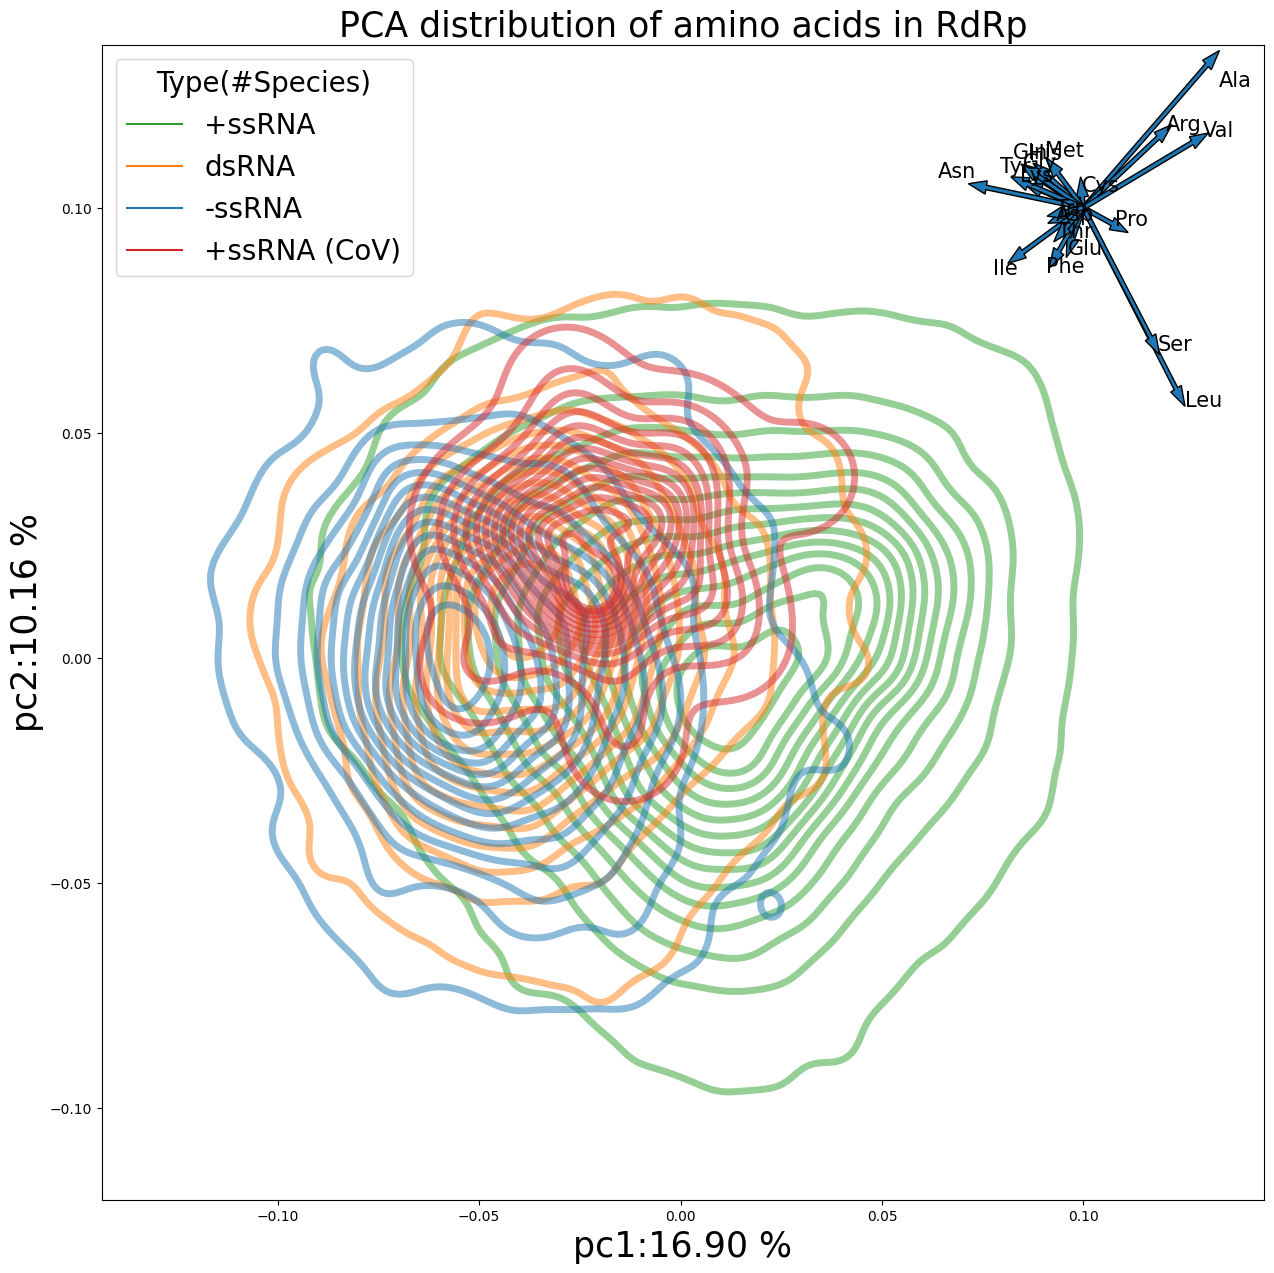

In [91]:
features = for_pca_train.columns
#for_pca_train['strand'] = emma_data_train['Strand'].to_list()
ldngs = pca_fit.components_
pca_data1['for_legend'] = ''
pca_data1.loc[pca_data1['strand'] == 'positive ','Type(#Species)'] = '+ssRNA'
pca_data1.loc[pca_data1['strand'] == 'negative' ,'Type(#Species)'] = '-ssRNA'
pca_data1.loc[pca_data1['strand'] == 'double' ,'Type(#Species)'] = 'dsRNA'
pca_data1.loc[pca_data1['Family'] == 'Coronaviridae' ,'Type(#Species)'] = '+ssRNA (CoV)'

pca_data1 = pca_data1.rename(columns={'Type(#Species)': 'Type'})

palette = {
    'dsRNA': 'tab:orange',
    '+ssRNA': 'tab:green',
    '-ssRNA': 'tab:blue',
    '+ssRNA (CoV)': 'tab:red'
}
plt.rcParams["figure.figsize"] = (15,15)
plt.rcParams['legend.fontsize'] = 20
plt.rcParams["legend.title_fontsize"] = 20
#plt.xlim([-0.23,0.23]) 
#plt.ylim([-0.13,0.11])
g=sns.kdeplot(data=pca_data1[pca_data1['taxid'].isna()], x="pc1", y="pc2", hue="Type", 
              alpha=0.5, palette=palette, legend=True, thresh=0.01, levels=15, common_norm=False, linewidths=5)


    
for i, feature in enumerate(features):
    plt.arrow(0.1, 0.1, ldngs[0, i]/15, 
             ldngs[1, i]/15)
    if ldngs[0, i]/5 > (ldngs[0]/5).mean():
        if feature == 'Ala':
            plt.text(0.1+ldngs[0, i]/15*1.1, 
                    0.1+ldngs[1, i]/15*1.1-0.008, 
                    feature, fontsize=15)
        else:
            plt.text(0.1+ldngs[0, i]/15*1.1, 
                    0.1+ldngs[1, i]/15*1.1, 
                    feature, fontsize=15)
    else:
        plt.text(0.1+ldngs[0, i]/15*1.5, 
                0.1+ldngs[1, i]/15*1.5, 
                feature, fontsize=15)
    
# for strand in eq_pca_data1['Family']:
#     if strand=='+ssRNA':
#         color='green'
#     elif strand=='-ssRNA':
#         color='blue'
#     elif strand=='dsRNA': 
#         color='orange'
#     elif strand=='+ssRNA(CoV)': 
#         color='red'
#     x_start = ref_mean_data[ref_mean_data['Family'] == strand]['pc1'].values[0]
#     y_start = ref_mean_data[ref_mean_data['Family'] == strand]['pc2'].values[0]
#     x_finish = eq_pca_data1[eq_pca_data1['Family'] == strand]['pc1'].values[0]
#     y_finish = eq_pca_data1[eq_pca_data1['Family'] == strand]['pc2'].values[0]
#     plt.annotate("",
#                 xy=(x_finish, y_finish), xycoords='data',
#                 xytext=(x_start, y_start), textcoords='data',
#                 arrowprops=dict(arrowstyle="simple, head_width=1.3, head_length=1.3", linewidth=21, 
#                                 color='black', alpha=0.5))
#     plt.annotate("",
#                 xy=(x_finish, y_finish), xycoords='data',
#                 xytext=(x_start, y_start), textcoords='data',
#                 arrowprops=dict(arrowstyle="simple, head_width=1.3, head_length=1.3", linewidth=20, 
#                                 color=color, alpha=0.4))



plt.xlabel("pc1:" + "{:.2f}".format(model.explained_variance_ratio_[0] * 100) + " %", fontsize=25)
plt.ylabel("pc2:" + "{:.2f}".format(model.explained_variance_ratio_[1] * 100) + " %", fontsize=25)

plt.title("PCA distribution of amino acids in RdRp", fontsize=25) 
plt.savefig('../figures/fig_3e_cov.pdf', dpi=300, bbox_inches = 'tight')
plt.show()
plt.close()

In [157]:
pca_data1

,pc1,pc2,Family,strand,Species,taxid,Type(#Species)
0,-0.060262,0.047420,Alphaflexiviridae,positive,u17540|Narcissus,NaN,+ssRNA
1,-0.035641,0.021329,Alphaflexiviridae,positive,u17602,NaN,+ssRNA
2,-0.063221,0.058957,Alphaflexiviridae,positive,u4329|Lily,NaN,+ssRNA
3,-0.048378,0.023632,Alphaflexiviridae,positive,u6633|Papaya,NaN,+ssRNA
4,-0.043162,0.039010,Alphaflexiviridae,positive,u11143,NaN,+ssRNA
...,...,...,...,...,...,...,...
77266,0.040088,0.030283,NaN,positive,Ref positive,54290,+ssRNA
77267,-0.014172,-0.017437,NaN,negative,Ref negative,57482,-ssRNA
77268,-0.026283,0.021518,NaN,positive,Ref positive,693997,+ssRNA
77269,-0.017246,0.022373,NaN,positive,Ref positive,694014,+ssRNA


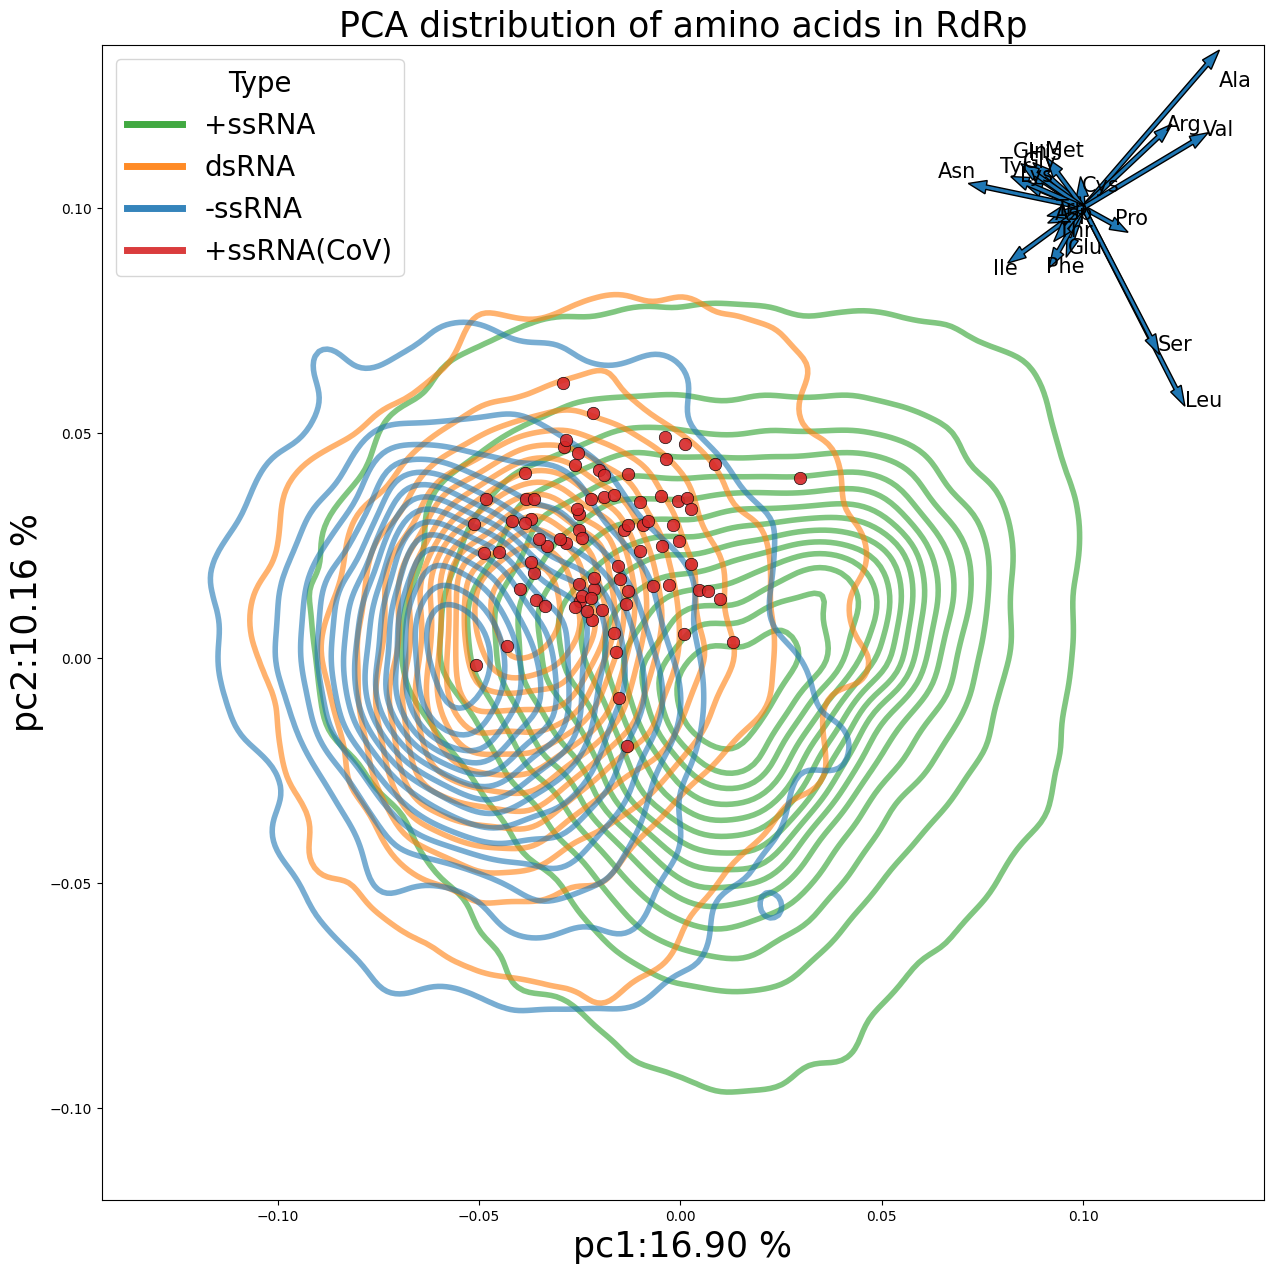

In [162]:
from matplotlib.lines import Line2D

pca_data1 = pca_data1.rename(columns={'Type(#Species)': 'Type'})
plot_data = pca_data1[pca_data1['taxid'].isna()].copy()

palette = {
    'dsRNA': 'tab:orange',
    '+ssRNA': 'tab:green',
    '-ssRNA': 'tab:blue',
    '+ssRNA(CoV)': 'tab:red'
}

fig, ax = plt.subplots(figsize=(15, 15))
plt.rcParams['legend.fontsize'] = 20
plt.rcParams["legend.title_fontsize"] = 20

# Сначала рисуем бледные группы
for group in ['+ssRNA', 'dsRNA', '-ssRNA']:
    group_data = plot_data[plot_data['Type'] == group]
    
    sns.kdeplot(
        data=group_data,
        x='pc1',
        y='pc2',
        color=palette[group],
        alpha=0.6,
        thresh=0.01,
        levels=15,
        linewidths=4,
        warn_singular=False,
        label=group,
        ax=ax)

# Красную группу рисуем последней, чтобы она была поверх остальных
cov_data = plot_data[
    plot_data['Type'] == '+ssRNA(CoV)'
]

ax.scatter(
    cov_data['pc1'],
    cov_data['pc2'],
    color=palette['+ssRNA(CoV)'],
    s=80,                  # размер точек
    alpha=0.9,
    edgecolor='black',     # можно убрать, если не нравится
    linewidth=0.5,
    label='+ssRNA(CoV)',
    zorder=10
)

for i, feature in enumerate(features):
    plt.arrow(0.1, 0.1, ldngs[0, i]/15, 
             ldngs[1, i]/15)
    if ldngs[0, i]/5 > (ldngs[0]/5).mean():
        if feature == 'Ala':
            plt.text(0.1+ldngs[0, i]/15*1.1, 
                    0.1+ldngs[1, i]/15*1.1-0.008, 
                    feature, fontsize=15)
        else:
            plt.text(0.1+ldngs[0, i]/15*1.1, 
                    0.1+ldngs[1, i]/15*1.1, 
                    feature, fontsize=15)
    else:
        plt.text(0.1+ldngs[0, i]/15*1.5, 
                0.1+ldngs[1, i]/15*1.5, 
                feature, fontsize=15)


# Создаём легенду вручную
legend_order = ['+ssRNA', 'dsRNA', '-ssRNA', '+ssRNA(CoV)']

legend_handles = [
    Line2D(
        [0], [0],
        color=palette[group],
        linewidth=5,
        alpha=0.9,
        label=group
    )
    for group in legend_order
]

plt.legend(
    handles=legend_handles,
    title='Type',
    loc='upper left'
)

plt.xlabel("pc1:" + "{:.2f}".format(model.explained_variance_ratio_[0] * 100) + " %", fontsize=25)
plt.ylabel("pc2:" + "{:.2f}".format(model.explained_variance_ratio_[1] * 100) + " %", fontsize=25)

plt.title("PCA distribution of amino acids in RdRp", fontsize=25) 
plt.savefig('../figures/fig_3e_cov.pdf', dpi=300, bbox_inches = 'tight')
plt.show()
plt.close()

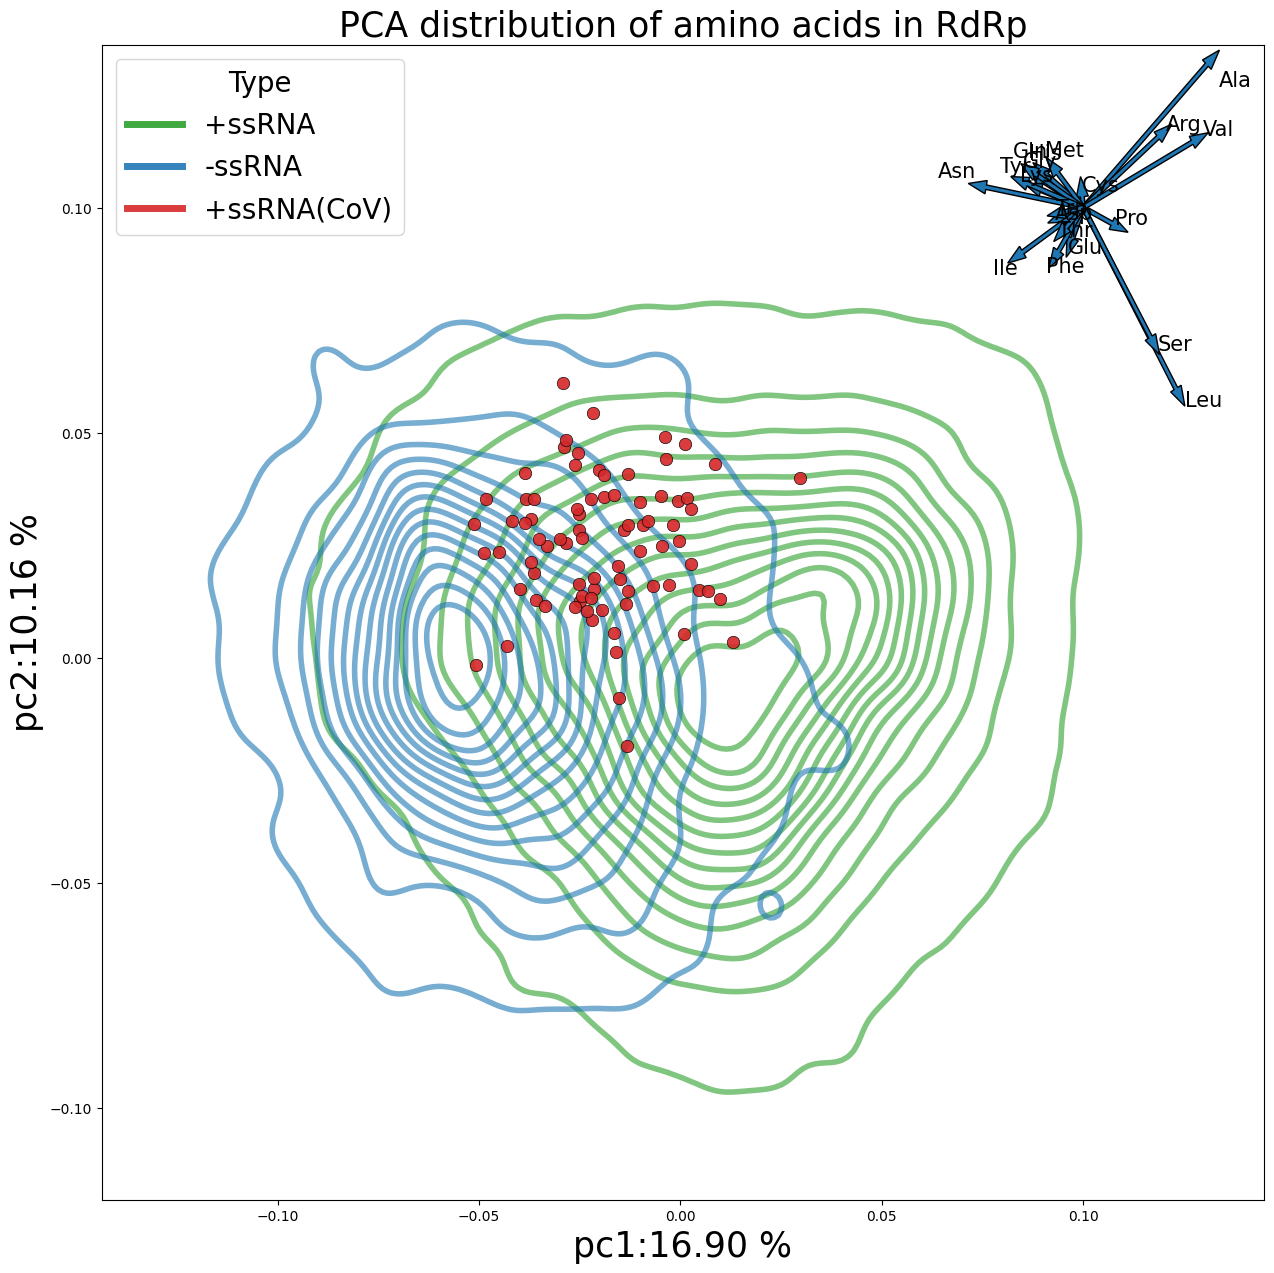

In [163]:
plot_data = pca_data1[pca_data1['taxid'].isna()].copy()

palette = {
    '+ssRNA': 'tab:green',
    '-ssRNA': 'tab:blue',
    '+ssRNA(CoV)': 'tab:red'
}

fig, ax = plt.subplots(figsize=(15, 15))
plt.rcParams['legend.fontsize'] = 20
plt.rcParams["legend.title_fontsize"] = 20

# Сначала рисуем бледные группы
for group in ['+ssRNA', '-ssRNA']:
    group_data = plot_data[plot_data['Type'] == group]
    
    sns.kdeplot(
        data=group_data,
        x='pc1',
        y='pc2',
        color=palette[group],
        alpha=0.6,
        thresh=0.01,
        levels=15,
        linewidths=4,
        warn_singular=False,
        label=group,
        ax=ax)

# Красную группу рисуем последней, чтобы она была поверх остальных
cov_data = plot_data[
    plot_data['Type'] == '+ssRNA(CoV)'
]

ax.scatter(
    cov_data['pc1'],
    cov_data['pc2'],
    color=palette['+ssRNA(CoV)'],
    s=80,                  # размер точек
    alpha=0.9,
    edgecolor='black',     # можно убрать, если не нравится
    linewidth=0.5,
    label='+ssRNA(CoV)',
    zorder=10
)

for i, feature in enumerate(features):
    plt.arrow(0.1, 0.1, ldngs[0, i]/15, 
             ldngs[1, i]/15)
    if ldngs[0, i]/5 > (ldngs[0]/5).mean():
        if feature == 'Ala':
            plt.text(0.1+ldngs[0, i]/15*1.1, 
                    0.1+ldngs[1, i]/15*1.1-0.008, 
                    feature, fontsize=15)
        else:
            plt.text(0.1+ldngs[0, i]/15*1.1, 
                    0.1+ldngs[1, i]/15*1.1, 
                    feature, fontsize=15)
    else:
        plt.text(0.1+ldngs[0, i]/15*1.5, 
                0.1+ldngs[1, i]/15*1.5, 
                feature, fontsize=15)

# Создаём легенду вручную
legend_order = ['+ssRNA', '-ssRNA', '+ssRNA(CoV)']

legend_handles = [
    Line2D(
        [0], [0],
        color=palette[group],
        linewidth=5,
        alpha=0.9,
        label=group
    )
    for group in legend_order
]

plt.legend(
    handles=legend_handles,
    title='Type',
    loc='upper left'
)

plt.xlabel("pc1:" + "{:.2f}".format(model.explained_variance_ratio_[0] * 100) + " %", fontsize=25)
plt.ylabel("pc2:" + "{:.2f}".format(model.explained_variance_ratio_[1] * 100) + " %", fontsize=25)

plt.title("PCA distribution of amino acids in RdRp", fontsize=25) 
plt.savefig('../figures/fig_3e_cov_nods.pdf', dpi=300, bbox_inches = 'tight')
plt.show()
plt.close()

In [100]:
emma_data_train_second = emma_data_train[emma_data_train['Strand'].isin(['positive ', 'negative'])]
for_pca_train_second = emma_data_train_second[emma_data_train_second.columns[5:-3]].reset_index(drop=True)

for_pca_train_second['total'] = for_pca_train_second.sum(axis=1)
for col in emma_data[emma_data_train.columns[5:-3]].columns:
    for_pca_train_second[col] = for_pca_train_second[col]/for_pca_train_second['total']
for_pca_train_second = for_pca_train_second.drop('total',axis=1)
for_pca_train_second = for_pca_train_second.fillna(0)

In [101]:
model = PCA(n_components=2)
pca_model_second = model.fit_transform(for_pca_train_second)

In [102]:
pca_data = pd.DataFrame(pca_model_second, columns=["pc1", 'pc2'])
pca_data1 = pca_data[["pc1","pc2"]].copy()

In [103]:
pca_data1['strand'] = emma_data_train_second['Strand'].to_list()
pca_data1['Species'] = emma_data_train_second['Species'].to_list()
pca_data1['taxid'] = emma_data_train_second['taxid'].to_list()

In [104]:
concat = pd.read_csv('../../data_obtain/plus_minus_predict.csv', index_col=0)
pivot_concat = concat.pivot(index=None, columns='aa', 
                        values=['count_predict_dif', 'predict_positive', 'predict_negative'])
melted_df = pd.melt(concat, 
                    id_vars=['aa'], 
                    value_vars=['count_predict_dif', 'predict_positive', 'predict_negative'],
                    var_name='metric', 
                    value_name='value')

# Затем делаем pivot
final_df = melted_df.pivot(index='metric', columns='aa', values='value').reset_index()

# Убираем название индекса колонок
final_df.columns.name = None

aa_list_emma_data_train_second = emma_data_train_second.columns[5:-3]
concta_to_transform_positive = final_df[final_df['metric']=='predict_positive'][list(aa_list_emma_data_train_second)]
concta_to_transform_negative = final_df[final_df['metric']=='predict_negative'][list(aa_list_emma_data_train_second)]

In [105]:
transformed_pred_pos = model.transform(concta_to_transform_positive)
df_transformed_pred_pos = pd.DataFrame(transformed_pred_pos, columns=["pc1", 'pc2'])
df_transformed_pred_pos['pc1'] = -df_transformed_pred_pos['pc1']
transformed_pred_neg = model.transform(concta_to_transform_negative)
df_transformed_pred_neg = pd.DataFrame(transformed_pred_neg, columns=["pc1", 'pc2'])
df_transformed_pred_neg['pc1'] = -df_transformed_pred_neg['pc1']
pca_data1['for_legend'] = ''
pca_data1.loc[pca_data1['strand'] == 'positive ','Type(#Species)'] = '+ssRNA'
pca_data1.loc[pca_data1['strand'] == 'negative' ,'Type(#Species)'] = '-ssRNA'
pca_data1['pc1'] = -pca_data1['pc1']

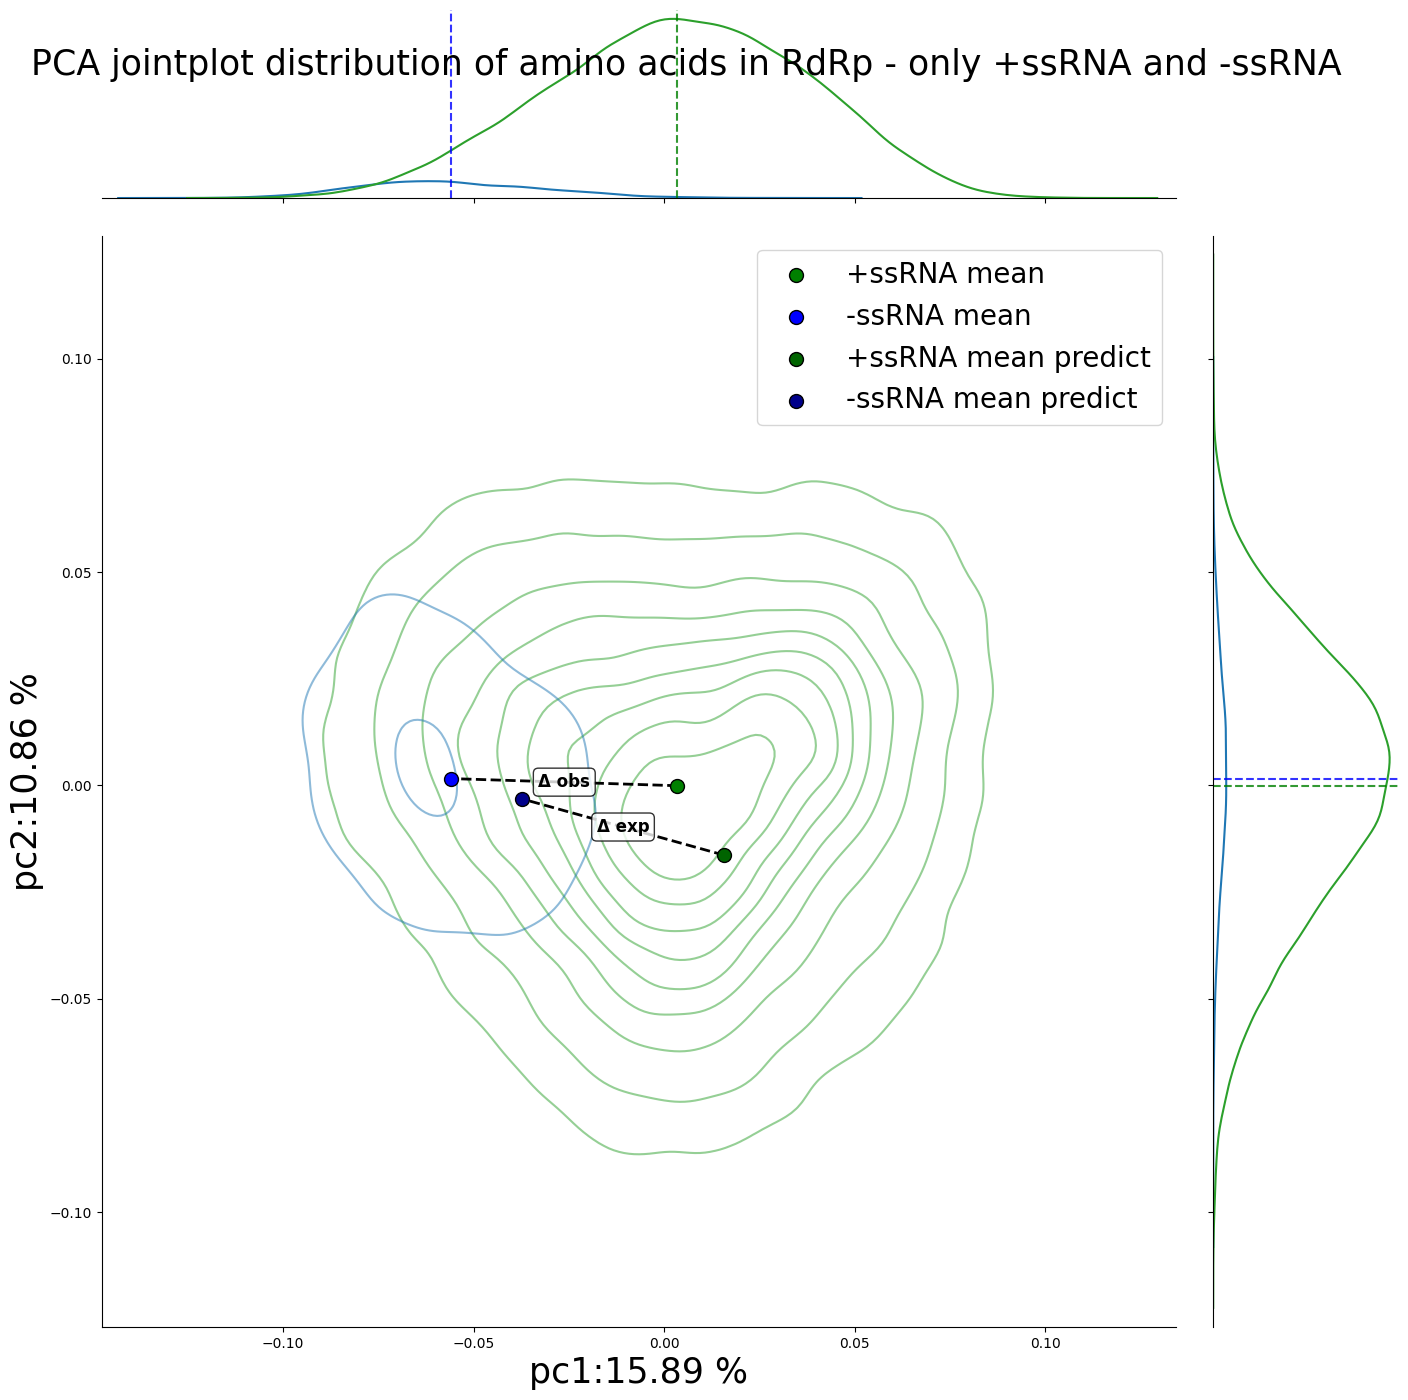

In [106]:

palette = {
    '+ssRNA': 'tab:green',
    '-ssRNA': 'tab:blue'
}

plt.rcParams["figure.figsize"] = (15,15)
plt.rcParams['legend.fontsize'] = 20
plt.rcParams["legend.title_fontsize"] = 20

g = sns.jointplot(data=pca_data1, x="pc1", y="pc2", hue="Type(#Species)", kind='kde', fill=False, alpha=0.5 , palette=palette, legend=True)
g.fig.set_size_inches(15, 15)
plt.xlabel("pc1:" + "{:.2f}".format(model.explained_variance_ratio_[0] * 100) + " %", fontsize=25)
plt.ylabel("pc2:" + "{:.2f}".format(model.explained_variance_ratio_[1] * 100) + " %", fontsize=25)

# Вычисляем средние значения для каждой группы
means = pca_data1.groupby('Type(#Species)')[['pc1', 'pc2']].mean()
mean_plus = means.loc['+ssRNA']
mean_minus = means.loc['-ssRNA']

# Добавляем точки средних значений на основной график
g.ax_joint.scatter(mean_plus['pc1'], mean_plus['pc2'], 
                  s=100, color='green', edgecolor='black', 
                  label='+ssRNA mean', zorder=10)
g.ax_joint.scatter(mean_minus['pc1'], mean_minus['pc2'], 
                  s=100, color='blue', edgecolor='black', 
                  label='-ssRNA mean', zorder=10)

# Добавляем точки средних предсказаний значений на основной график
g.ax_joint.scatter(df_transformed_pred_pos['pc1'], df_transformed_pred_pos['pc2'], 
                  s=100, color='darkgreen', edgecolor='black', 
                  label='+ssRNA mean predict', zorder=10)
g.ax_joint.scatter(df_transformed_pred_neg['pc1'], df_transformed_pred_neg['pc2'], 
                  s=100, color='darkblue', edgecolor='black', 
                  label='-ssRNA mean predict', zorder=10)

# Рисуем линию между средними точками
g.ax_joint.plot([mean_plus['pc1'], mean_minus['pc1']],
               [mean_plus['pc2'], mean_minus['pc2']],
               color='black', linestyle='--', linewidth=2
               # , label='Delta between means observed'
               )

# Вычисляем середину линии для подписи
mid_x = (mean_plus['pc1'] + mean_minus['pc1']) / 2
mid_y = (mean_plus['pc2'] + mean_minus['pc2']) / 2

# Добавляем подпись "delta exp"
g.ax_joint.text(mid_x, mid_y, 'Δ obs', 
               fontsize=12, fontweight='bold',
               ha='center', va='center',
               bbox=dict(boxstyle="round,pad=0.3", 
                        facecolor="white", 
                        edgecolor="black", 
                        alpha=0.8))

# Рисуем линию между предсказаниями
g.ax_joint.plot([df_transformed_pred_pos['pc1'], df_transformed_pred_neg['pc1']],
               [df_transformed_pred_pos['pc2'], df_transformed_pred_neg['pc2']],
               color='black', linestyle='--', linewidth=2
               # ,label='Delta between means expected'
               )

# Вычисляем середину линии для подписи для exp
mid_x_pred = (df_transformed_pred_pos['pc1'] + df_transformed_pred_neg['pc1']) / 2
mid_y_pred = (df_transformed_pred_pos['pc2'] + df_transformed_pred_neg['pc2']) / 2

# Добавляем подпись "delta exp"
g.ax_joint.text(mid_x_pred, mid_y_pred, 'Δ exp', 
               fontsize=12, fontweight='bold',
               ha='center', va='center',
               bbox=dict(boxstyle="round,pad=0.3", 
                        facecolor="white", 
                        edgecolor="black", 
                        alpha=0.8))

# Добавляем легенду
g.ax_joint.legend(loc='best')

# Добавляем средние значения также на маргинальные графики
# Для оси X (сверху)
g.ax_marg_x.axvline(mean_plus['pc1'], color='green', linestyle='--', alpha=0.8)
g.ax_marg_x.axvline(mean_minus['pc1'], color='blue', linestyle='--', alpha=0.8)

# Для оси Y (справа)
g.ax_marg_y.axhline(mean_plus['pc2'], color='green', linestyle='--', alpha=0.8)
g.ax_marg_y.axhline(mean_minus['pc2'], color='blue', linestyle='--', alpha=0.8)


#plt.title("PCA jointplot distribution of amino acids in RdRp - only +ssRNA and -ssRNA", fontsize=25) 
g.fig.suptitle("PCA jointplot distribution of amino acids in RdRp - only +ssRNA and -ssRNA", 
               fontsize=25, y=0.95)
plt.savefig('../figures/suppfig_su.pdf', dpi=300, bbox_inches = 'tight')
plt.show()
plt.close()

In [107]:
pc1_weights = -1 * model.components_[0]
print("\nВеса для первой компоненты (PC1):")
print(pc1_weights)


Веса для первой компоненты (PC1):
[ 0.5312471  -0.03123331 -0.03540914 -0.07835255 -0.05506335 -0.17605524
 -0.10794589 -0.18880018 -0.18468965  0.2489859  -0.10641338 -0.39517077
  0.12664735 -0.14504945  0.26911232  0.27423706 -0.04805548  0.36403786
 -0.20390491 -0.05812429]


In [108]:
predict_diff = final_df[final_df['metric']=='count_predict_dif'][list(aa_list_emma_data_train_second)]

In [109]:
predict_diff_list = predict_diff.iloc[0].tolist()

In [110]:
correlation, p_value = stats.spearmanr(pc1_weights, predict_diff_list)

print(f"Корреляция Спирмена: {correlation:.3f}")
print(f"P-value: {p_value:.4f}")

# Интерпретация
if p_value < 0.001:
    significance = "***"
elif p_value < 0.01:
    significance = "**"
elif p_value < 0.05:
    significance = "*"
else:
    significance = "не значимо"

print(f"Статистическая значимость: {significance}")

Корреляция Спирмена: 0.734
P-value: 0.0002
Статистическая значимость: ***


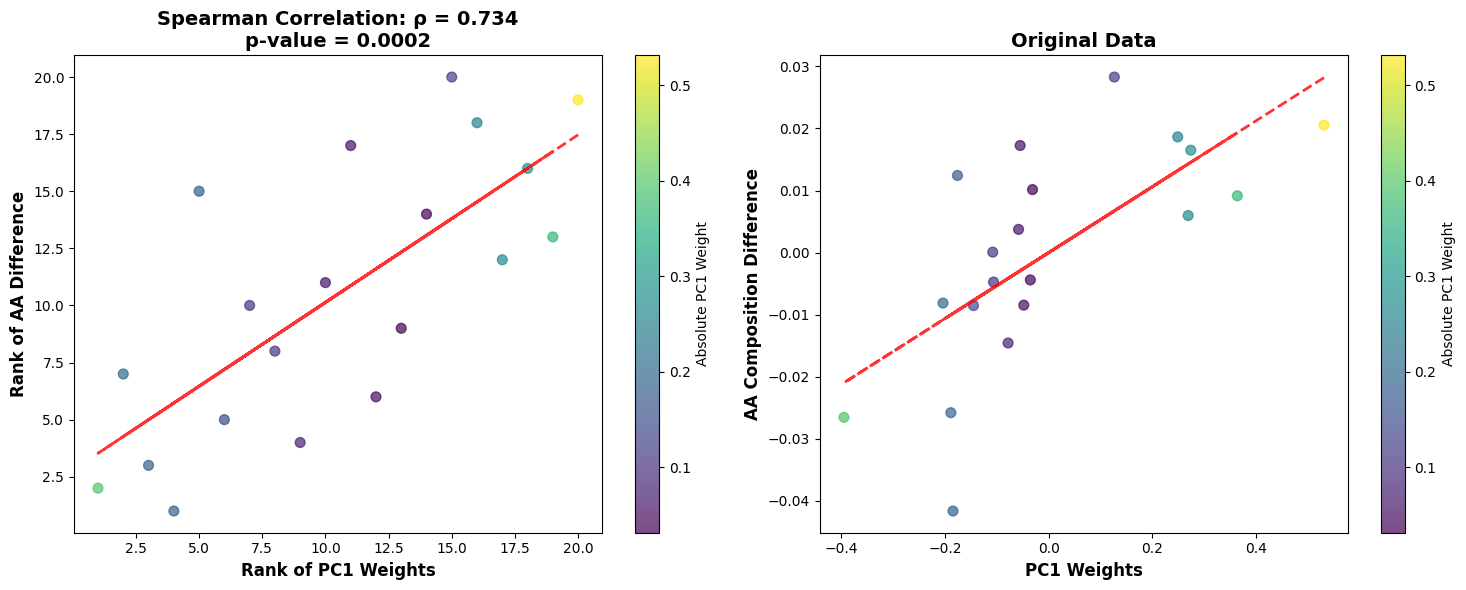

In [111]:
x = pc1_weights  # веса PC1
y = predict_diff_list  # разница аминокислотного состава

# Вычисляем корреляцию
corr, p_value = stats.spearmanr(x, y)

# Считаем ранги
x_ranks = stats.rankdata(x)
y_ranks = stats.rankdata(y)

# Создаем график
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. Scatter plot рангов
scatter = ax1.scatter(x_ranks, y_ranks, alpha=0.7, c=np.abs(x), cmap='viridis', s=50)
ax1.set_xlabel('Rank of PC1 Weights', fontsize=12, fontweight='bold')
ax1.set_ylabel('Rank of AA Difference', fontsize=12, fontweight='bold')
ax1.set_title(f'Spearman Correlation: ρ = {corr:.3f}\np-value = {p_value:.4f}', 
              fontsize=14, fontweight='bold')

# Добавляем линию тренда для рангов
z_rank = np.polyfit(x_ranks, y_ranks, 1)
p_rank = np.poly1d(z_rank)
ax1.plot(x_ranks, p_rank(x_ranks), "r--", alpha=0.8, linewidth=2)

# 2. Scatter plot исходных данных
scatter2 = ax2.scatter(x, y, alpha=0.7, c=np.abs(x), cmap='viridis', s=50)
ax2.set_xlabel('PC1 Weights', fontsize=12, fontweight='bold')
ax2.set_ylabel('AA Composition Difference', fontsize=12, fontweight='bold')
ax2.set_title('Original Data', fontsize=14, fontweight='bold')

# Добавляем линию тренда для исходных данных
z_orig = np.polyfit(x, y, 1)
p_orig = np.poly1d(z_orig)
ax2.plot(x, p_orig(x), "r--", alpha=0.8, linewidth=2)

# Добавляем цветовую шкалу
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('Absolute PC1 Weight', fontsize=10)
cbar2 = plt.colorbar(scatter2, ax=ax2)
cbar2.set_label('Absolute PC1 Weight', fontsize=10)

plt.tight_layout()
plt.savefig('../figures/suppfig_sw.pdf', dpi=300, bbox_inches = 'tight')
plt.show()
plt.close()

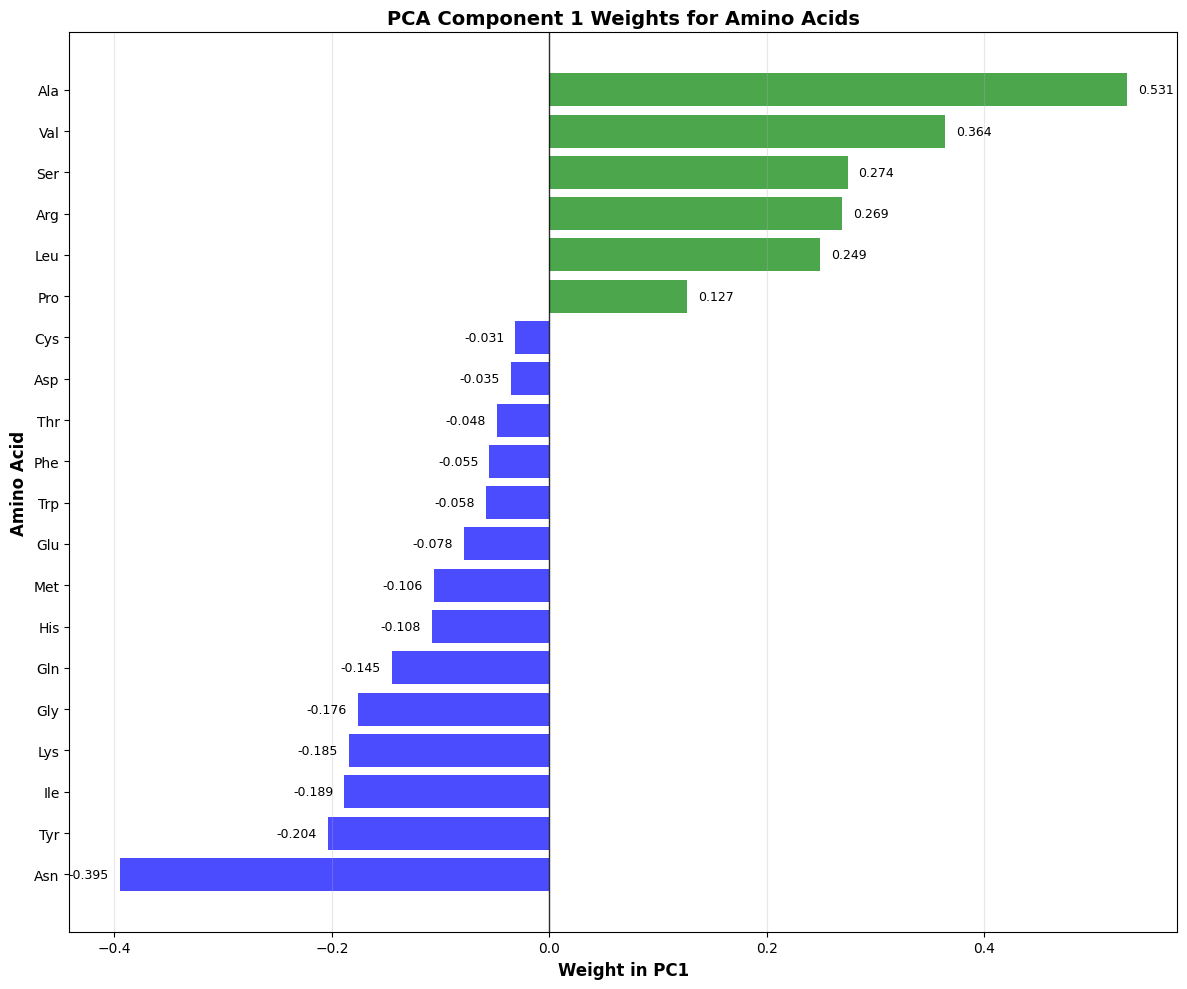

In [112]:
df = pd.DataFrame({'Amino_Acid': list(for_pca_train_second.columns), 'PC1_Weight': list(-1 * model.components_[0, :])})
df_sorted = df.sort_values('PC1_Weight')

# Создаем график
plt.figure(figsize=(12, 10))
colors = ['blue' if x < 0 else 'green' for x in df_sorted['PC1_Weight']]

bars = plt.barh(df_sorted['Amino_Acid'], df_sorted['PC1_Weight'], color=colors, alpha=0.7)

# Добавляем значения на bars
for bar in bars:
    width = bar.get_width()
    if width > 0:
        plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{width:.3f}', ha='left', va='center', fontsize=9)
    else:
        plt.text(width - 0.01, bar.get_y() + bar.get_height()/2, 
                f'{width:.3f}', ha='right', va='center', fontsize=9)

plt.axvline(x=0, color='black', linestyle='-', alpha=0.8, linewidth=1)
plt.xlabel('Weight in PC1', fontsize=12, fontweight='bold')
plt.ylabel('Amino Acid', fontsize=12, fontweight='bold')
plt.title('PCA Component 1 Weights for Amino Acids', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/supp_16.pdf', dpi=300, bbox_inches = 'tight')
plt.show()
plt.close()

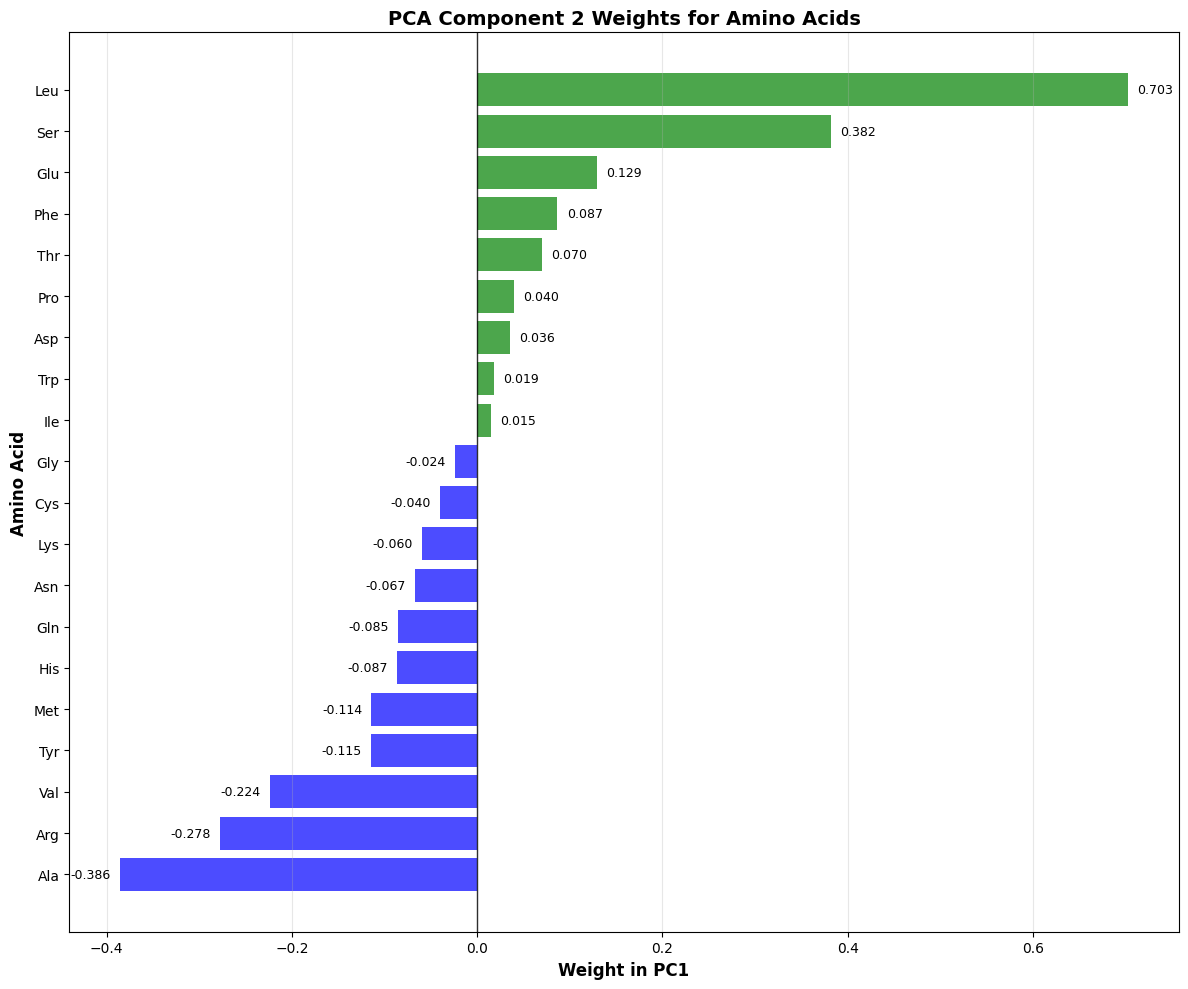

In [113]:
df = pd.DataFrame({'Amino_Acid': list(for_pca_train_second.columns), 'PC2_Weight': list(-1 * model.components_[1, :])})
df_sorted = df.sort_values('PC2_Weight')

# Создаем график
plt.figure(figsize=(12, 10))
colors = ['blue' if x < 0 else 'green' for x in df_sorted['PC2_Weight']]

bars = plt.barh(df_sorted['Amino_Acid'], df_sorted['PC2_Weight'], color=colors, alpha=0.7)

# Добавляем значения на bars
for bar in bars:
    width = bar.get_width()
    if width > 0:
        plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{width:.3f}', ha='left', va='center', fontsize=9)
    else:
        plt.text(width - 0.01, bar.get_y() + bar.get_height()/2, 
                f'{width:.3f}', ha='right', va='center', fontsize=9)

plt.axvline(x=0, color='black', linestyle='-', alpha=0.8, linewidth=1)
plt.xlabel('Weight in PC1', fontsize=12, fontweight='bold')
plt.ylabel('Amino Acid', fontsize=12, fontweight='bold')
plt.title('PCA Component 2 Weights for Amino Acids', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/supp_16_B.pdf', dpi=300, bbox_inches = 'tight')
plt.show()
plt.close()